In [ ]:
import matplotlib.pyplot as plt # For ploting field
from os.path import isfile
import itertools

from sys import path # Needed if running code from repo
path.append("../../../")

import larp # Our tool [pip install Larp]
import larp.io as lpio 
import numpy as np

import osmnx as ox # Used to load building data based on address [pip install osmnx]

edges = [0.01, 0.2, 0.5, 0.8]
penalty_scaler = lambda p: 1/(1.1*(1.0 - p + 1e-10))

address = "Purdue University, West Lafayette, IN"
distance_from_address = 1000

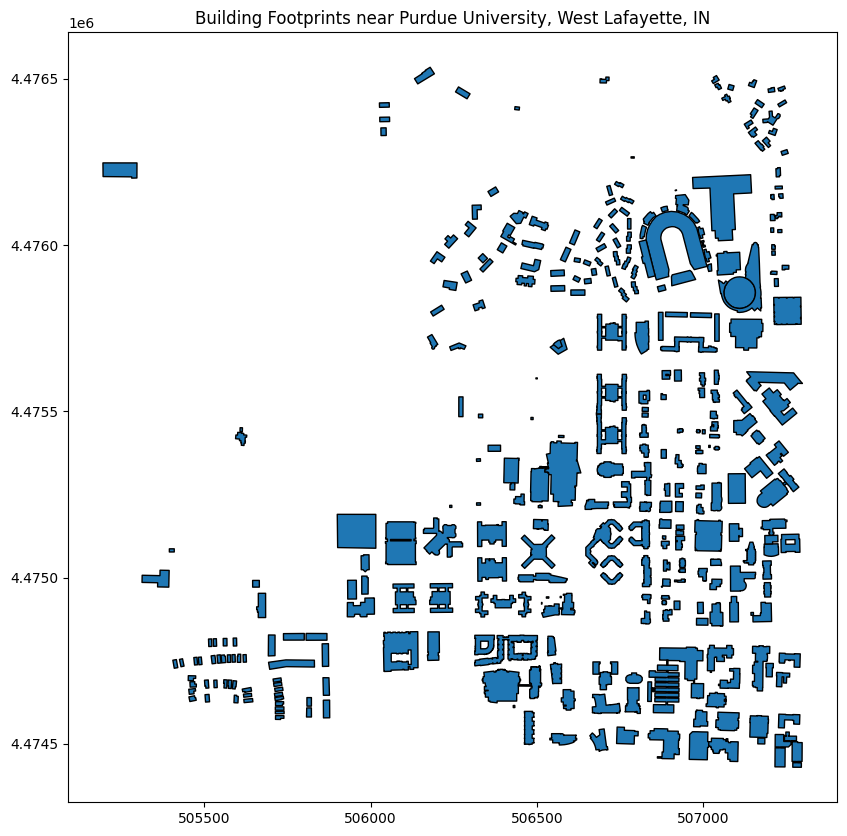

In [2]:
# Define the address and search radius
buildings = ox.features_from_address(address, tags={'building': True}, dist=distance_from_address)

# Optional: filter for Polygon geometries and project
buildings = buildings[buildings.geometry.geom_type == 'Polygon']
buildings = ox.projection.project_gdf(buildings)
west, south, east, north = buildings.total_bounds

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, edgecolor='black')
ax.set_title(f'Building Footprints near {address}')
plt.show()

In [ ]:
# First time, it will be a bit slow since it needs to build the quadtree
# map.quad.lp
if isfile('.rug_purdue.quad.lp'):
    quadtree, field = lpio.loadQuadTreeFile('.rug_purdue.quad.lp', return_field=True)
else:
    # Convert to GeoJSON
    field = lpio.loadGeoJSON(buildings.to_json())
    field.set_all_repulsion([[25.0, 0.0], [0.0, 25.0]])

    field.reload_center_point(False)
    field.size = np.array((east - west, north-south))
    field.center_point = np.array(((east + west)/2.0, (north + south)/2.0))

    quadtree = larp.quad.QuadTree(field, minimum_length_limit=2.5, edge_bounds=edges, build_tree=True)
    lpio.saveQuadTree(quadtree, file='.rug_purdue.quad.lp')

planner = larp.pp.QuadPlanner(quadtree, "a*") # To generate paths in map
qfield = larp.QPotentailField(quadtree) # To speed up calculations and sync quadtree and potential field

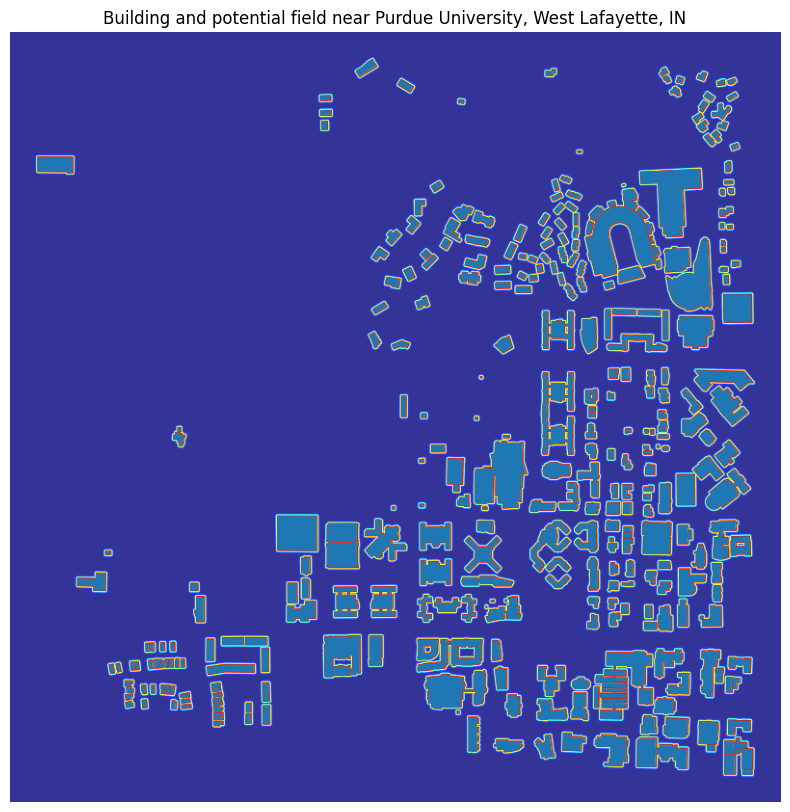

In [4]:
margin = 80
display, extent = qfield.to_image(resolution=800, margin=margin, max_depth=5)

# Plot potential field
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title(f'Building and potential field near {address}')
buildings.plot(ax=ax, zorder=2)
img = ax.imshow(display, cmap='jet', extent=extent, alpha=0.8, zorder=1)
ax.axis(False)
img.set_clim(0.0, 1.0)
plt.show()

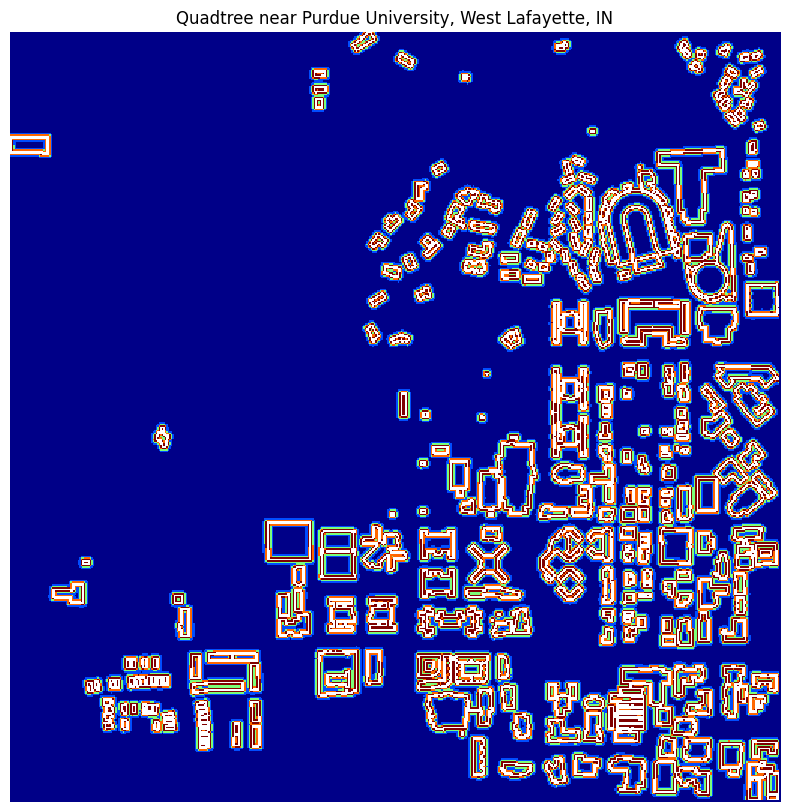

In [5]:
display_q, extent_q = quadtree.to_image(return_extent=True)

# Plot the quad sectors image
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title(f'Quadtree near {address}')
img = ax.imshow(display_q, cmap='jet', extent=extent_q, interpolation='nearest')
ax.axis(False)
img.set_clim(0.0, 1.0)
plt.show()

In [ ]:
def held_karp_tsp(points):
    n = len(points)
    dist = np.linalg.norm(points[:, np.newaxis] - points[np.newaxis, :], axis=2)
    C = {}

    # Initialize with direct distances from the starting city to each other city
    for k in range(1, n):
        C[(1 << k, k)] = (dist[0, k], 0)

    # Iterate through subsets of increasing size
    for subset_size in range(2, n):
        for subset in itertools.combinations(range(1, n), subset_size):
            bits = 0
            for bit in subset:
                bits |= 1 << bit
            for k in subset:
                prev_bits = bits & ~(1 << k)
                res = []
                for m in subset:
                    if m == k:
                        continue
                    res.append((C[(prev_bits, m)][0] + dist[m, k], m))
                C[(bits, k)] = min(res)

    # Final step: return to starting city
    bits = (1 << n) - 2
    res = []
    for k in range(1, n):
        res.append((C[(bits, k)][0] + dist[k, 0], k))
    _, parent = min(res)

    # Reconstruct the optimal path
    path = [0]
    bits = (1 << n) - 2
    last = parent
    for _ in range(n - 1):
        path.append(last)
        new_bits = bits & ~(1 << last)
        _, last = C[(bits, last)]
        bits = new_bits
    path.append(0)

    return points[path]


locations = np.random.random((10, 2))*field.size + np.array(field.bbox[0])

while any([qfield.in_bbox(location) for location in locations]):
    locations = np.random.random((10, 2))*field.size + np.array(field.bbox[0])

locations = held_karp_tsp(locations) # Delivery order
starts, ends = locations[:-1], locations[1:]

In [7]:
paths = []

for start, end in zip(starts, ends):
    path = planner.find_path(start, end, scaler=penalty_scaler, refresh_network=False)
    paths.append(path)

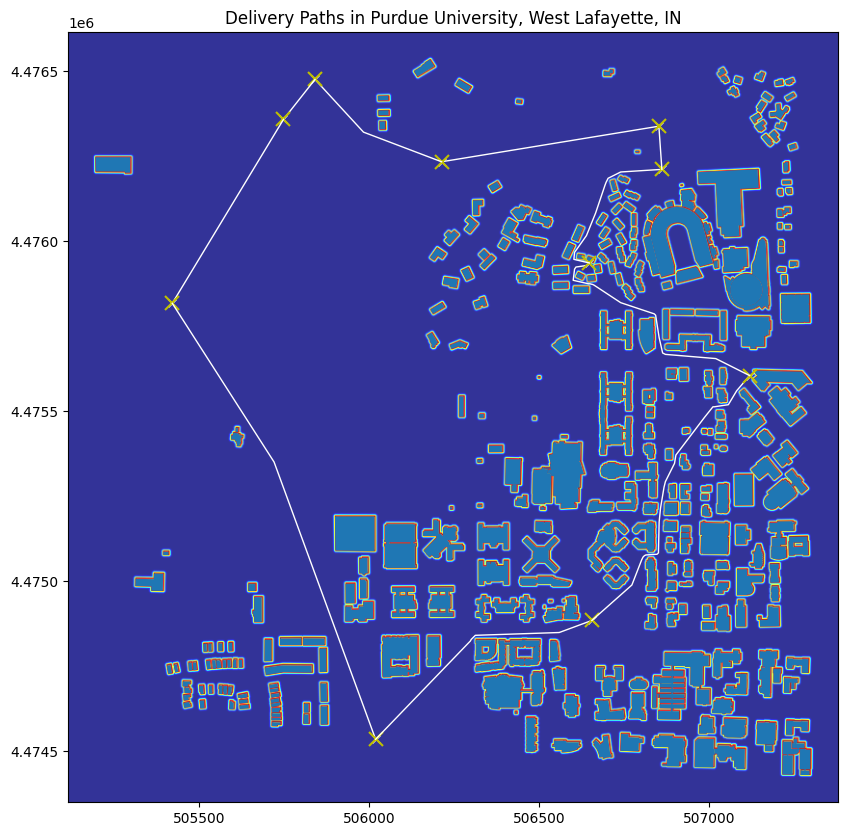

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, zorder=2)
ax.imshow(display, cmap='jet', extent=extent, alpha=0.8)
ax.set_title(f'Delivery Paths in {address}')

for path, start, end in zip(paths, starts, ends):

    if path is None:
        ax.plot(start[0], start[1], 'rx', markersize=10.0, markeredgewidth=1.5)
        ax.plot(end[0], end[1], 'r4', markersize=10.0, markeredgewidth=1.5)
    else:
        ax.plot(path[:, 0], path[:, 1], color="#fff", alpha=1.0, linewidth=1.0)
        # plt.plot(path[0, 0], path[0, 1], 'r4', markersize=10.0, markeredgewidth=1.5)
        ax.plot(path[-1, 0], path[-1, 1], 'wx')
        ax.plot(end[0], end[1], 'yx', markersize=10.0, markeredgewidth=1.5)

img.set_clim(0.0, 1.0)
plt.show()